# Predicting a Continuous Target with Regression (Titanic)

**Name:** Sabriya Sowers  
**Date:** November 12, 2025

## Introduction
This analysis uses the Titanic passenger dataset to develop predictive models for estimating **fare**, a continuous financial variable representing the amount paid for passage. The dataset includes a wide range of demographic and travel-related attributes—such as passenger class, age, sex, and ticket characteristics—that may influence fare levels.


**Section 1: Import and Inspect the Data**

In [ ]:
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, ElasticNet
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# Load Titanic dataset from seaborn and verify
titanic = sns.load_dataset("titanic")

# Display first 10 rows
print(titanic.head(10))

# Check for missing values
titanic.isnull().sum()

   survived  pclass     sex   age  sibsp  parch     fare embarked   class  \
0         0       3    male  22.0      1      0   7.2500        S   Third   
1         1       1  female  38.0      1      0  71.2833        C   First   
2         1       3  female  26.0      0      0   7.9250        S   Third   
3         1       1  female  35.0      1      0  53.1000        S   First   
4         0       3    male  35.0      0      0   8.0500        S   Third   
5         0       3    male   NaN      0      0   8.4583        Q   Third   
6         0       1    male  54.0      0      0  51.8625        S   First   
7         0       3    male   2.0      3      1  21.0750        S   Third   
8         1       3  female  27.0      0      2  11.1333        S   Third   
9         1       2  female  14.0      1      0  30.0708        C  Second   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

**Section 2: Data Exploration and Preparation**

In [153]:
# Handle missing values in age using the median
titanic['age'] = titanic['age'].fillna(titanic['age'].median())

# Remove rows with missing fare values (our target variable)
titanic = titanic.dropna(subset=['fare'])

# Create a new engineered feature: family size (passenger + relatives aboard)
titanic['family_size'] = titanic['sibsp'] + titanic['parch'] + 1

**Section 3: Feature Selection and Justification**

In [154]:
# Case 1. age
X1 = titanic[['age']]
y1 = titanic['fare']

In [155]:
# Case 2. family_size
X2 = titanic[['family_size']]
y2 = titanic['fare']

In [156]:
# Case 3. age, family_size
X3 = titanic[['age', 'family_size']]
y3 = titanic['fare']

In [157]:
# Case 4. pclass, age, family_size (all numeric)
X4 = titanic[['pclass', 'age', 'family_size']]
y4 = titanic['fare']

3.1 Histograms (distribution of numeric features)

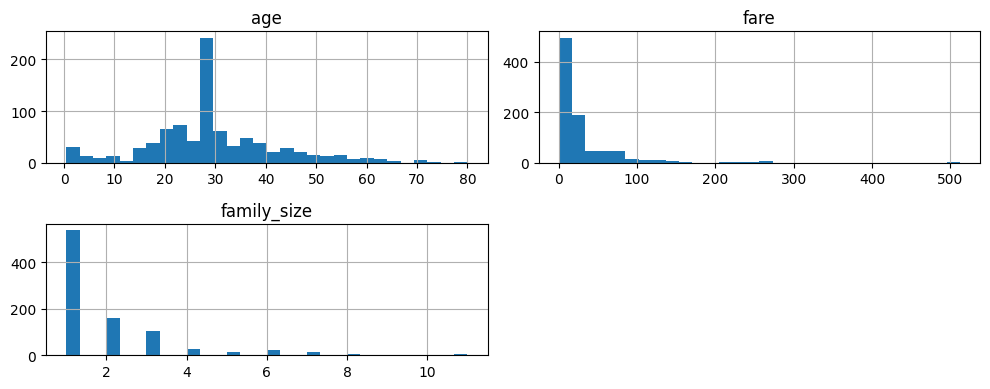

In [158]:
titanic[['age', 'fare', 'family_size']].hist(bins=30, figsize=(10,4))
plt.tight_layout()
plt.show()

3.2 Boxplots (detect outliers)

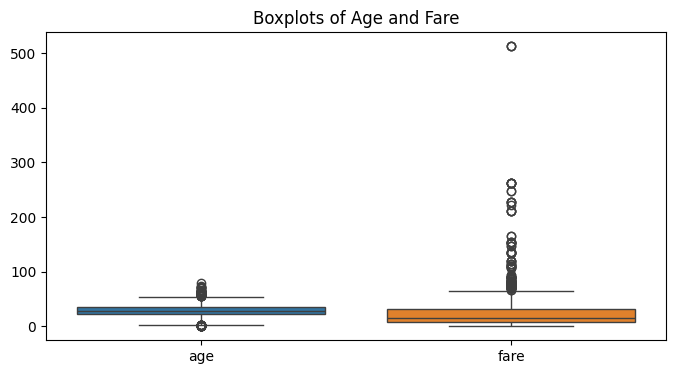

In [159]:
plt.figure(figsize=(8,4))
sns.boxplot(data=titanic[['age', 'fare']])
plt.title("Boxplots of Age and Fare")
plt.show()

3.3 Countplots (categorical features)

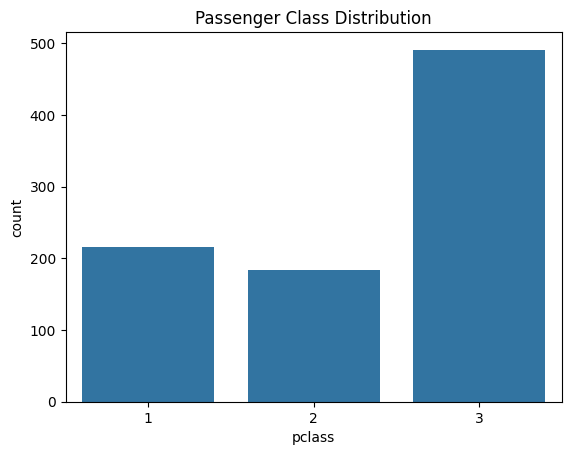

In [160]:
sns.countplot(x='pclass', data=titanic)
plt.title("Passenger Class Distribution")
plt.show()

3.4 Scatterplots (relationships with the target)

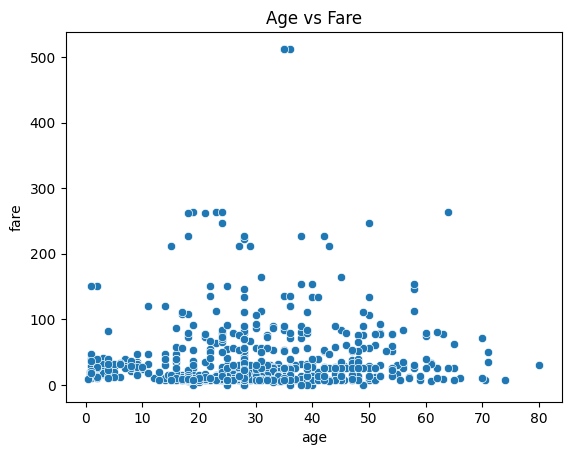

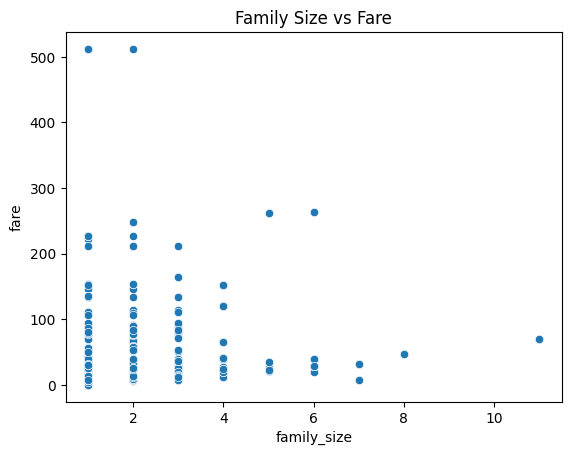

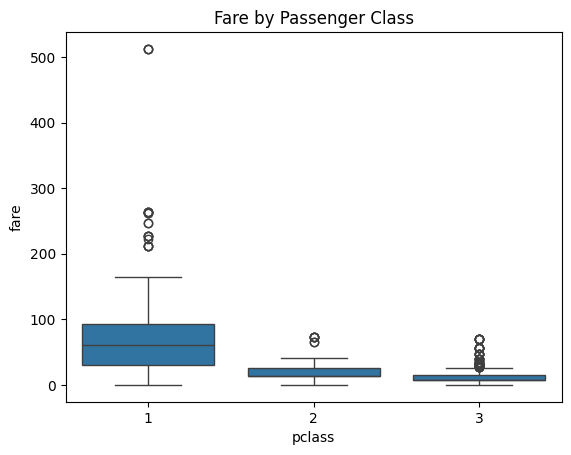

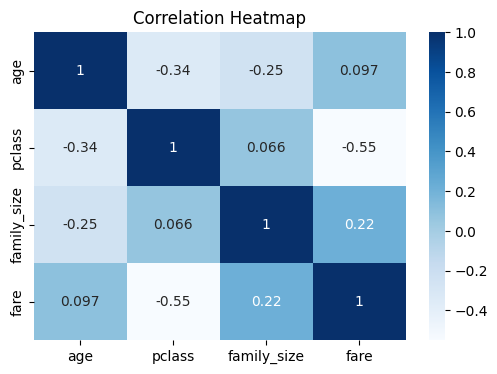

In [161]:
# Age vs Fare
sns.scatterplot(x='age', y='fare', data=titanic)
plt.title("Age vs Fare")
plt.show()

# Family Size vs Fare
sns.scatterplot(x='family_size', y='fare', data=titanic)
plt.title("Family Size vs Fare")
plt.show()

# Passenger Class vs Fare
sns.boxplot(x='pclass', y='fare', data=titanic)
plt.title("Fare by Passenger Class")
plt.show()

# Correlation Heatmap
plt.figure(figsize=(6,4))
sns.heatmap(titanic[['age','pclass','family_size','fare']].corr(), annot=True, cmap='Blues')
plt.title("Correlation Heatmap")
plt.show()

**Reflection 1:**

** Visual Insights**
### Visual Insights
- **Age vs Fare:** There is no strong linear relationship between age and fare. Fares vary widely at all ages, suggesting age alone is not a strong predictor.
- **Family Size vs Fare:** Smaller families (around 1–3 people) show higher variability in fares, including the highest. Larger family sizes tend to have lower fares, possibly due to group accommodations or lower-class cabins.
- **Correlation Heatmap:** Passenger class has the strongest negative correlation with fare (–0.55) confirming that higher classes paid more. Age has almost no correlation with fare, while family size shows a weak positive relationship.
- **Fare by Passenger Class:** This boxplot shows a clear separation among classes. First-class passengers paid significantly more on average, with more high-fare outliers. Second and third class fares are much lower and tightly grouped. This reinforces that `pclass` is a key predictor in regression models.

**Why might these features affect a passenger’s fare?**
- **Age:** Fare pricing may differ for adults and children.  
- **Family size:** Larger families may share cabins or qualify for group pricing, which can influence fare.  
- **Passenger class (pclass):** This is one of the strongest predictors of fare because higher classes paid significantly more for premium accommodations.

**List all available features**
- survived  
- pclass  
- sex  
- age  
- sibsp  
- parch  
- ticket  
- fare  
- cabin  
- embarked  
- family_size *(engineered)*  

**Which other features could improve predictions and why?**
- **sex:** Could capture differences in cabin assignment or class distribution.
- **embarked:** Fares varied by port of departure.
- **cabin:** Reflects accommodation quality which will vary.  
- **ticket:** Ticket groups or fare classes may relate to pricing patterns.

**How many variables are in your Case 4?**
Three variables

**Which variable(s) did you choose for Case 4 and why?**
I selected **pclass, age, and family_size**.  
- **pclass** is directly tied to ticket pricing.  
- **age** captures pricing differences between adults and children.  
- **family_size** reflects group travel behavior and shared accommodations.  
Together these features provide a stronger foundation for predicting fare than using a single variable.

**Section 4: Train a Regression Model (Linear Regression)**

**4.1 Split the Data**

In [162]:
# Case 1
X1_train, X1_test, y1_train, y1_test = train_test_split(X1, y1, test_size=0.2, random_state=123)
# Case 2
X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y2, test_size=0.2, random_state=123)
# Case 3
X3_train, X3_test, y3_train, y3_test = train_test_split(X3, y3, test_size=0.2, random_state=123)
# Case 4
X4_train, X4_test, y4_train, y4_test = train_test_split(X4, y4, test_size=0.2, random_state=123)

4.2 Train and Evaluate Linear Regression Models (all 4 cases)

In [163]:
lr_model1 = LinearRegression().fit(X1_train, y1_train)
lr_model2 = LinearRegression().fit(X2_train, y2_train)
lr_model3 = LinearRegression().fit(X3_train, y3_train)
lr_model4 = LinearRegression().fit(X4_train, y4_train)

# Predictions for cases 1-4
y_pred_train1 = lr_model1.predict(X1_train)
y_pred_test1 = lr_model1.predict(X1_test)

y_pred_train2 = lr_model2.predict(X2_train)
y_pred_test2 = lr_model2.predict(X2_test)

y_pred_train3 = lr_model3.predict(X3_train)
y_pred_test3 = lr_model3.predict(X3_test)

y_pred_train4 = lr_model4.predict(X4_train)
y_pred_test4 = lr_model4.predict(X4_test)

4.3 Report Performance

In [166]:
# Case 1
mse1 = mean_squared_error(y1_test, y_pred_test1)
rmse1 = np.sqrt(mse1)
print("Case 1: Training R²:", r2_score(y1_train, y_pred_train1))
print("Case 1: Test R²:", r2_score(y1_test, y_pred_test1))
print("Case 1: Test RMSE:", rmse1)
print("Case 1: Test MAE:", mean_absolute_error(y1_test, y_pred_test1))

# Case 2
mse2 = mean_squared_error(y2_test, y_pred_test2)
rmse2 = np.sqrt(mse2)
print("Case 2: Training R²:", r2_score(y2_train, y_pred_train2))
print("Case 2: Test R²:", r2_score(y2_test, y_pred_test2))
print("Case 2: Test RMSE:", rmse2)
print("Case 2: Test MAE:", mean_absolute_error(y2_test, y_pred_test2))

# Case 3
mse3 = mean_squared_error(y3_test, y_pred_test3)
rmse3 = np.sqrt(mse3)
print("Case 3: Training R²:", r2_score(y3_train, y_pred_train3))
print("Case 3: Test R²:", r2_score(y3_test, y_pred_test3))
print("Case 3: Test RMSE:", rmse3)
print("Case 3: Test MAE:", mean_absolute_error(y3_test, y_pred_test3))

# Case 4
mse4 = mean_squared_error(y4_test, y_pred_test4)
rmse4 = np.sqrt(mse4)
print("Case 4: Training R²:", r2_score(y4_train, y_pred_train4))
print("Case 4: Test R²:", r2_score(y4_test, y_pred_test4))
print("Case 4: Test RMSE:", rmse4)
print("Case 4: Test MAE:", mean_absolute_error(y4_test, y_pred_test4))

Case 1: Training R²: 0.009950688019452314
Case 1: Test R²: 0.0034163395508415295
Case 1: Test RMSE: 37.97164180172938
Case 1: Test MAE: 25.28637293162364
Case 2: Training R²: 0.049915792364760736
Case 2: Test R²: 0.022231186110131973
Case 2: Test RMSE: 37.6114940041967
Case 2: Test MAE: 25.02534815941641
Case 3: Training R²: 0.07347466201590014
Case 3: Test R²: 0.049784832763073106
Case 3: Test RMSE: 37.0777586646559
Case 3: Test MAE: 24.284935030470688
Case 4: Training R²: 0.36396753488910505
Case 4: Test R²: 0.3855521972173821
Case 4: Test RMSE: 29.815698763780848
Case 4: Test MAE: 20.16225215201267


**Reflection 2:**

**Compare Train vs Test Results for Each Case**
**Did Case 1 overfit or underfit? Explain:**  
Case 1 underfit. Both training R² (0.01) and test R² (0.00) are extremely low, showing that the model did not learn meaningful patterns. Age alone is not predictive of fare, so the model remains weak on both training and testing data.

**Did Case 2 overfit or underfit? Explain:**  
Case 2 underfit. Training R² (0.05) and test R² (0.02) are still very low. Family size does not have a strong linear relationship with fare and the model captures very little structure in the data.

**Did Case 3 overfit or underfit? Explain:**  
Case 3 underfit. Adding age + family_size improved performance slightly, but both train (0.07) and test (0.05) R² remain low. The model is too simple to capture the factors driving fare.

**Did Case 4 overfit or underfit? Explain:**  
Case 4 generalizes well and does not appear to overfit. Training R² is 0.36 and test R² is 0.39, which are very close. The model is strong enough to capture meaningful patterns, mainly because `pclass` is highly predictive.

### Adding Age
**Did adding age improve the model?**  
Only slightly. From Case 2 → Case 3, R² improved a bit and errors decreased.

**Possible explanation:**  
Age likely has *some* connection to fare (children vs adults), but not a strong or consistent one. The scatterplot showed wide variation in fares across all ages. The data does not support a strong linear relationship between age and fare.

### Worst Model
**Which case performed the worst?**  
Case 1 (Age only).

**How do you know?**  
It had the lowest R² (near zero) and the highest MAE and RMSE. The model could not explain any real variation in fare.

**Would more training data help? Why or why not?**  
Probably not. The issue is not the amount of data, but that **age is not predictive of fare**. Adding more data would not create a relationship that doesn’t exist.

### Best Model
**Which case performed the best?**  
Case 4 (pclass, age, family_size).

**How do you know?**  
It had the highest training and test R² (~0.38), the lowest RMSE (~29.8), and the lowest MAE (~20). Adding `pclass` made the model much stronger.

**Would more training data help? Why or why not?**  
Possibly. Because the model is capturing real structure (pclass → fare), more data might slightly improve performance. But the major gains already came from using a meaningful feature, not from sample size.

**Section 5: Compare Alternative Models (Ridge, Elastic Net, Polynomial Regression)**

**Section 6: Final Thoughts & Insights**